In [17]:
from imodels.tree.rf_plus.rf_plus.rf_plus_models import RandomForestPlusRegressor
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
from sklearn.linear_model import LinearRegression

import os
import sys
import pandas as pd
import numpy as np
import sklearn.base
from sklearn.base import RegressorMixin, ClassifierMixin
from sklearn.metrics import mean_squared_error, log_loss
from functools import reduce
import shap
import lime
from imodels.tree.rf_plus.rf_plus.rf_plus_models import RandomForestPlusRegressor, RandomForestPlusClassifier
from sklearn.ensemble import RandomForestRegressor
from imodels.tree.rf_plus.feature_importance.rfplus_explainer import *
from sklearn.ensemble import GradientBoostingClassifier

In [18]:
X_361254 = pd.read_csv("361254/X.csv")
y_361254 = pd.read_csv("361254/y.csv")

X_361254 = X_361254.sample(n=100, random_state=42).values
y_361254 = y_361254.sample(n=100, random_state=42).values

In [19]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_361254, y_361254.ravel())

rf_plus_inbag = RandomForestPlusRegressor(rf_model=rf, include_raw=False, fit_on="inbag", prediction_model=LinearRegression())
rf_plus_inbag.fit(X_361254, y_361254.ravel(), n_jobs=None)

In [20]:
rf_plus_mdi = LMDIPlus(rf_plus_inbag, evaluate_on="inbag")
lmdi= np.abs(rf_plus_mdi.get_lmdi_plus_scores(X=X_361254))#, y=y_361254)
threshold = 1e-10  # pick based on your noise scale
lmdi[np.abs(lmdi) < threshold] = 0
lmdi

array([[2.24598403, 0.69636475, 0.76887967, ..., 0.04877177, 0.05966822,
        3.04083359],
       [1.66267652, 0.17845573, 0.31296852, ..., 0.43344708, 0.04411719,
        2.83444672],
       [3.02906171, 0.34614561, 0.42938112, ..., 0.2873936 , 0.01817163,
        2.55909167],
       ...,
       [1.812295  , 0.0036359 , 0.11546489, ..., 0.64891782, 0.07328009,
        2.16025693],
       [0.99441011, 0.58520503, 0.06110876, ..., 0.06142581, 0.02489097,
        3.60382377],
       [0.45182236, 1.24156842, 0.06128021, ..., 1.11656421, 0.12928258,
        2.90658863]])

In [21]:
# write lmdi to csv
np.savetxt("our_lmdi_scores.csv", lmdi, delimiter=",")

In [22]:
import numpy as np
import sklearn.ensemble

def compute_mdi_local_tree(tree, X, vimp):
    nsamples, nfeatures = X.shape

    impurity = tree.impurity
    threshold = tree.threshold
    children_left = tree.children_left
    children_right = tree.children_right
    features = tree.feature

    for i in range(nsamples):
        node = 0
        oldvimp = impurity[node]

        while children_left[node] != -1:
            ifeat = features[node]
            if X[i, ifeat] <= threshold[node]:
                node = children_left[node]
            else:
                node = children_right[node]
            newvimp = impurity[node]
            vimp[i, ifeat] += oldvimp - newvimp
            oldvimp = newvimp

def compute_mdi_local_ens(ens, X, verbose=0):
    nsamples, nfeatures = X.shape
    # vimp = np.zeros((nsamples, ens.n_features_), dtype='float64')
    vimp = np.zeros((nsamples, nfeatures), dtype='float64')

    for i, est in enumerate(ens.estimators_):
        if verbose > 0:
            print("o", end='', flush=True)
        compute_mdi_local_tree(est.tree_, X, vimp)

    if verbose > 0:
        print("")

    vimp /= ens.n_estimators
    return vimp

In [23]:
lmdi_baseline = compute_mdi_local_ens(rf, X_361254)
lmdi_baseline

array([[18.56990982,  4.76881105,  7.19101979, ...,  4.66537594,
         2.47959069, 55.65146112],
       [30.45247033,  4.40992753,  3.59121071, ...,  9.7702204 ,
         5.10716903, 62.15169562],
       [25.36214539,  3.79720757,  3.21744957, ...,  8.58566619,
         2.98026626, 58.25833909],
       ...,
       [14.82568327,  1.76034934,  4.55027637, ...,  3.56084617,
         4.22575148, 59.15705255],
       [14.25583234,  5.67662272,  6.48486437, ...,  4.01652872,
         1.65914266, 55.83317287],
       [ 4.39502099,  8.22783629,  4.28797107, ..., 10.37981312,
         2.22071725, 45.53286447]])

In [24]:
np.savetxt("sutera_lmdi_scores.csv", lmdi_baseline, delimiter=",")

In [25]:
feature_corrs = [
    np.corrcoef(lmdi_baseline[:, j], lmdi[:, j])[0, 1]
    for j in range(lmdi.shape[1])
]

print("Correlation per feature:", feature_corrs)
print("Mean correlation across features:", np.nanmean(feature_corrs))

Correlation per feature: [0.6358126074281868, 0.37607375556996686, 0.3588526403094284, 0.4732641342557352, 0.42387418697466983, 0.5438443612926123, 0.6328014523911236, 0.31571972410812715, 0.5532158490034638, 0.4047533208098435, 0.3416602011308574, 0.5551530565705703, 0.6278530332938317, 0.7892857673425068, 0.5885726327199051, 0.5854505586541056, -0.9386390293273132, 0.6243196805803112, 0.10162114282878826, 0.5127448794012145, -0.5899355914989755]
Mean correlation across features: 0.3769665887542362


In [26]:
# get sample-wise rank based correlation
from scipy.stats import spearmanr, kendalltau
spearman_corrs = [
    spearmanr(lmdi_baseline[:, j], lmdi[:, j])[0]
    for j in range(lmdi.shape[1])
]
kendall_corrs = [
    kendalltau(lmdi_baseline[:, j], lmdi[:, j])[0]
    for j in range(lmdi.shape[1])
]

In [27]:
spearman_corrs

[0.5907830783078307,
 0.4562376237623762,
 0.36613261326132607,
 0.4449684968496849,
 0.3715331533153315,
 0.5684608460846083,
 0.6607740774077407,
 0.2284308430843084,
 0.4312511251125112,
 0.33804980498049797,
 0.2635223522352235,
 0.36666066606660663,
 0.5206840684068407,
 0.5174797479747973,
 0.040828082808280826,
 0.39282328232823277,
 0.1129192919291929,
 0.3512511251125113,
 0.2802280228022802,
 0.5851065106510651,
 -0.23269126912691265]

In [28]:
sample_corrs = [
    np.corrcoef(lmdi_baseline[i, :], lmdi[i, :])[0, 1]
    for i in range(lmdi.shape[0])
]

print("Correlation per sample:", sample_corrs)
print("Mean correlation across samples:", np.nanmean(sample_corrs))

Correlation per sample: [0.9146984689258401, 0.9680359296747559, 0.38881549863533393, 0.8911271733514124, 0.6724901761776386, 0.3603490159071132, 0.43045175538537706, 0.5491610147737184, 0.6861546105274627, 0.49938597993023326, 0.7737765327908557, 0.9032574325037255, 0.5526112720975506, 0.9424853653109435, 0.12186840703241922, 0.6819673619099137, 0.9552886903925489, 0.24701384754085373, 0.9388679967148428, 0.4731710319061979, 0.8098775412852658, 0.757343661531158, 0.9581708332790699, 0.23643625210144148, 0.9454694992228159, 0.6131373737949352, 0.8854649320779128, 0.8646643373419896, 0.7523835725736595, 0.9349728653485005, 0.9554819432926522, 0.9506951729049306, 0.9433194692371478, 0.9432863412600356, 0.4851408815408197, 0.7592449778425322, 0.8104885320802937, 0.6346692000743297, 0.5529822364584304, 0.6513494580786819, 0.7633941847445682, 0.9555086669118743, 0.9214358951837786, 0.8504344355737117, 0.3716261724541934, 0.8961958380008164, 0.7161257062054804, 0.9786943906336883, 0.76575718

In [29]:
mask1 = (lmdi_baseline == 0)
mask2 = (lmdi == 0)

print(np.all(mask1 == mask2))

True


In [30]:
np.unique(lmdi_baseline[:,0])

array([ 0.70190485,  0.82961709,  0.83291144,  0.84080039,  0.91722779,
        0.92855437,  1.23961951,  1.28494893,  2.70370986,  3.20922002,
        3.26904944,  4.0186064 ,  4.39502099,  4.80281443,  5.43729519,
        5.83750958,  6.41573718,  6.60888667,  7.73037349,  7.81358645,
        8.44558033,  8.53875637,  8.82036788,  9.07982725,  9.52546699,
        9.68158878, 10.14787338, 10.71535506, 10.98502544, 11.12487204,
       11.83272561, 12.75901897, 12.87274698, 12.92868837, 12.93941658,
       12.95607998, 13.49213546, 13.92752287, 13.94972548, 14.25583234,
       14.35654529, 14.82568327, 14.84276411, 15.33651528, 15.38184969,
       16.20846853, 16.28710879, 16.32307409, 16.36799781, 16.49170758,
       16.54838172, 16.5687555 , 16.63741626, 16.64642038, 16.65925481,
       17.32561915, 17.44384531, 18.26521214, 18.44738849, 18.56990982,
       18.60962816, 18.66184697, 18.92517337, 19.10744378, 19.24991703,
       19.25383618, 19.38826751, 19.47362135, 19.74988169, 20.57

In [31]:
np.unique(lmdi[:,0])

array([0.0380842 , 0.04949076, 0.05473051, 0.09363019, 0.09455012,
       0.10569145, 0.12849281, 0.14329834, 0.16133495, 0.168446  ,
       0.17259434, 0.21571171, 0.22384164, 0.24695228, 0.2545099 ,
       0.25817872, 0.29079708, 0.32372113, 0.36700395, 0.37778045,
       0.45182236, 0.46059571, 0.4750583 , 0.48611777, 0.59794884,
       0.62334215, 0.63022472, 0.74325946, 0.75851587, 0.80352834,
       0.87587114, 0.91028631, 0.9182648 , 0.94945855, 0.96023657,
       0.99441011, 1.08720345, 1.16542157, 1.19209594, 1.22089708,
       1.2727057 , 1.27981725, 1.3309341 , 1.33399121, 1.3643934 ,
       1.38363359, 1.41900036, 1.48968221, 1.55648419, 1.59949448,
       1.61514202, 1.62847526, 1.66267652, 1.77474009, 1.79817005,
       1.812295  , 1.8345645 , 1.90774951, 1.94109668, 2.01979786,
       2.04593926, 2.09297611, 2.13390858, 2.13893215, 2.17676712,
       2.17988188, 2.18357474, 2.19800822, 2.21549175, 2.23334595,
       2.24598403, 2.34830075, 2.43436183, 2.50317859, 2.52131

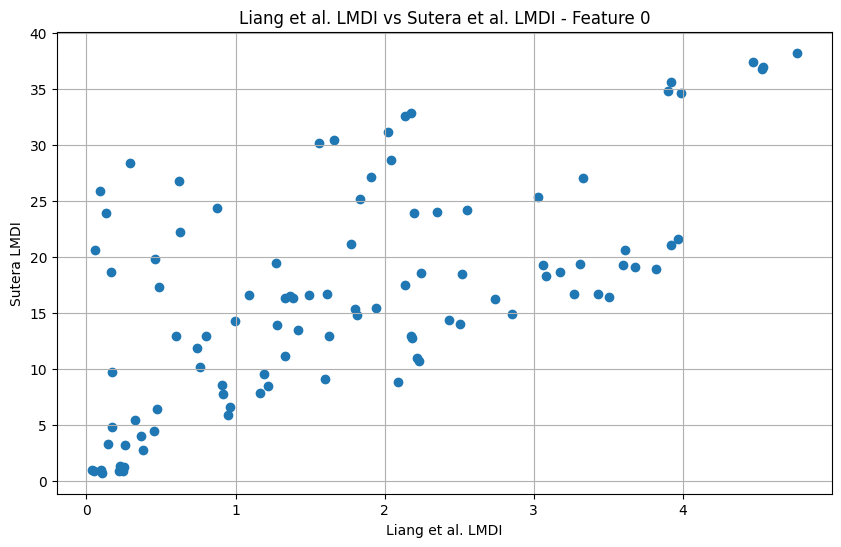

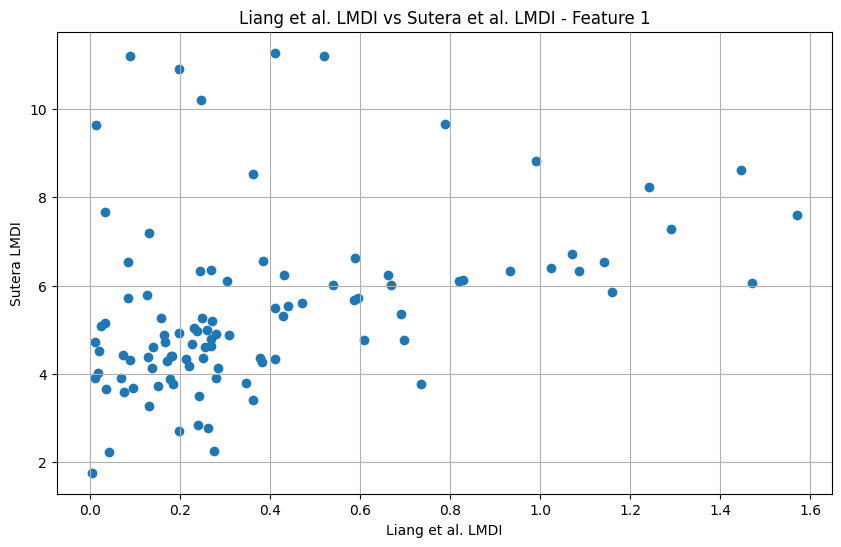

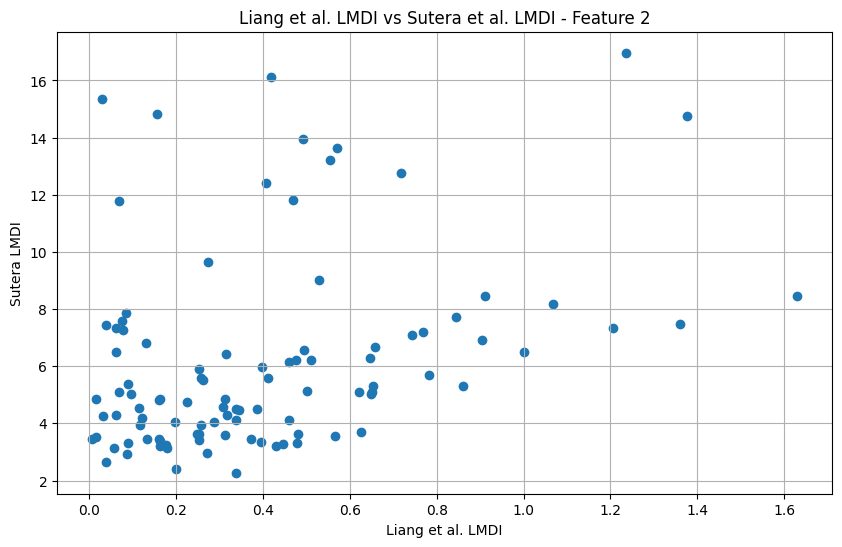

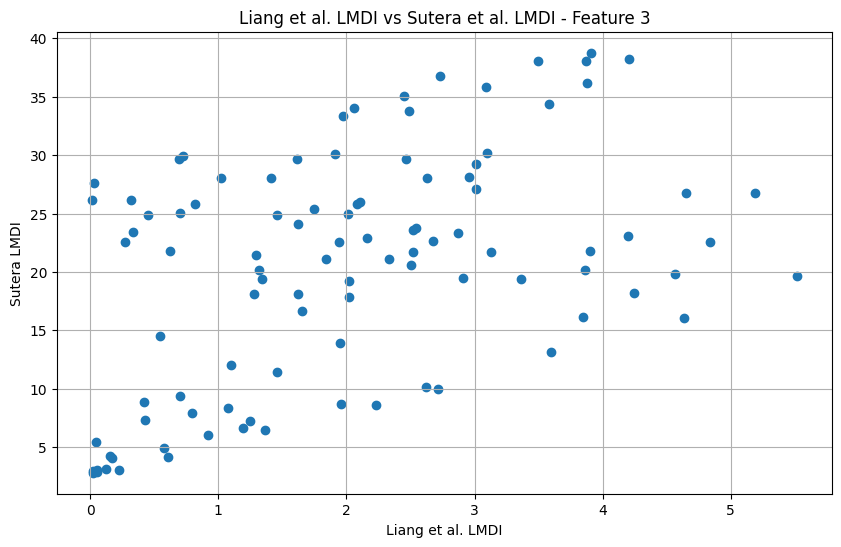

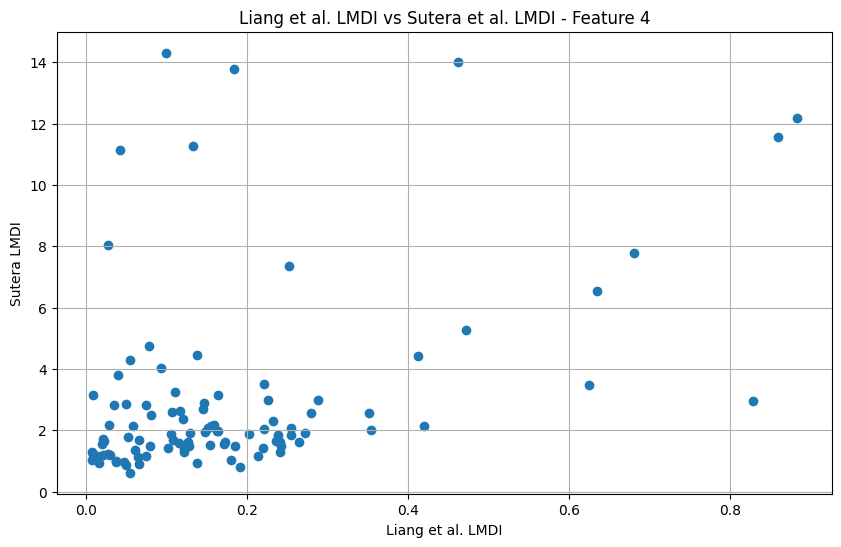

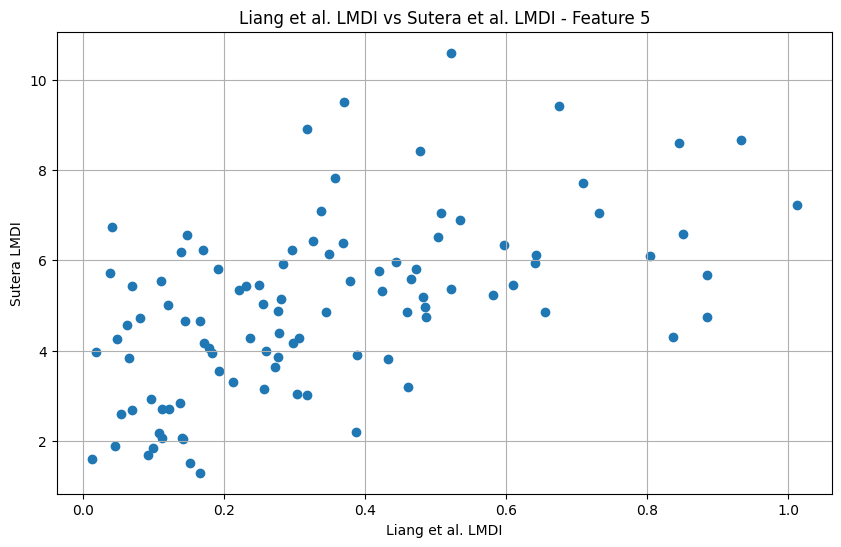

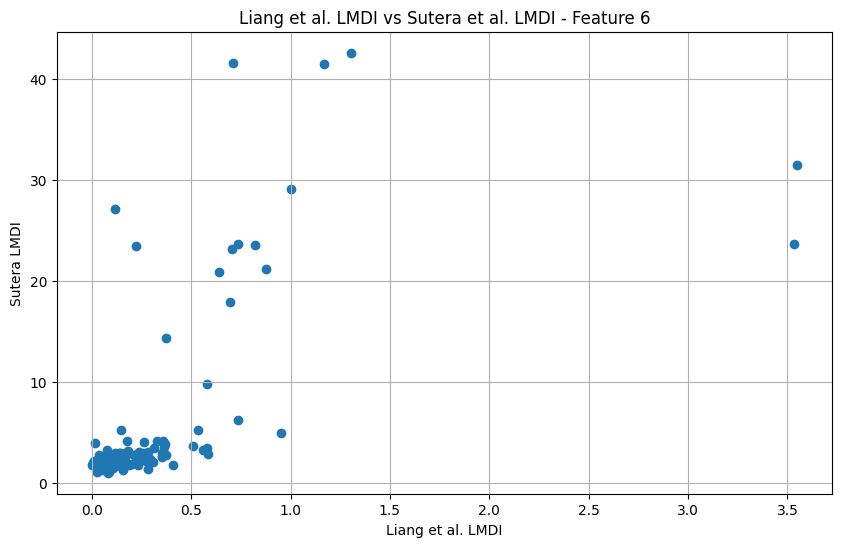

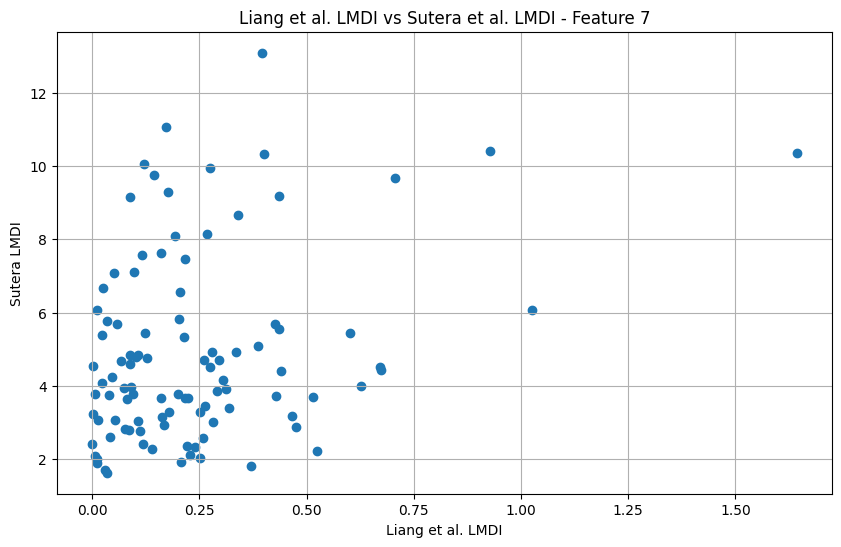

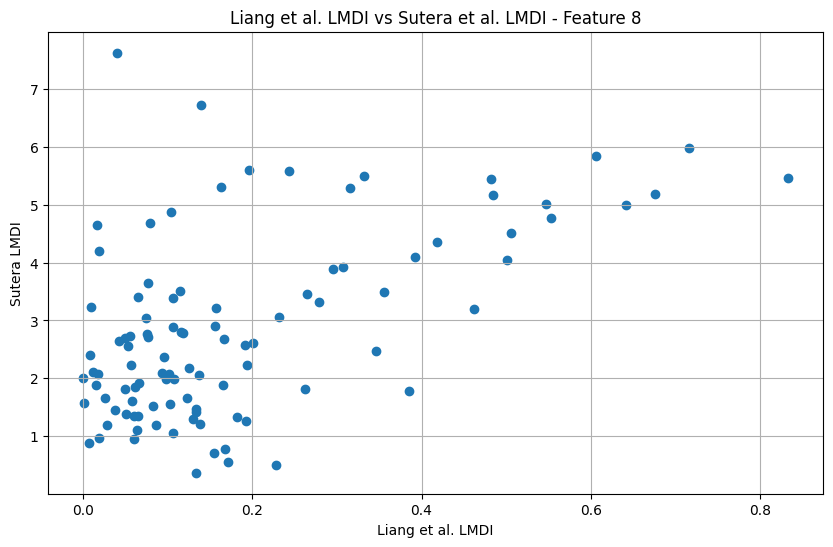

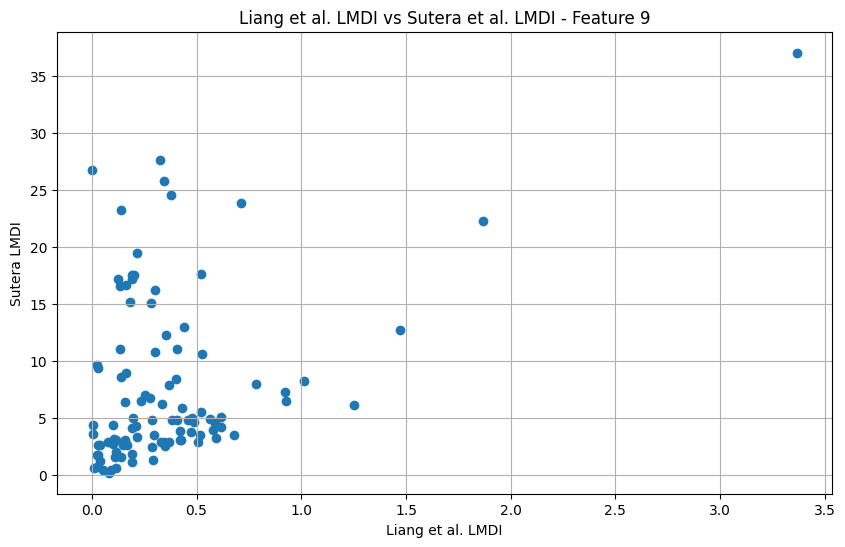

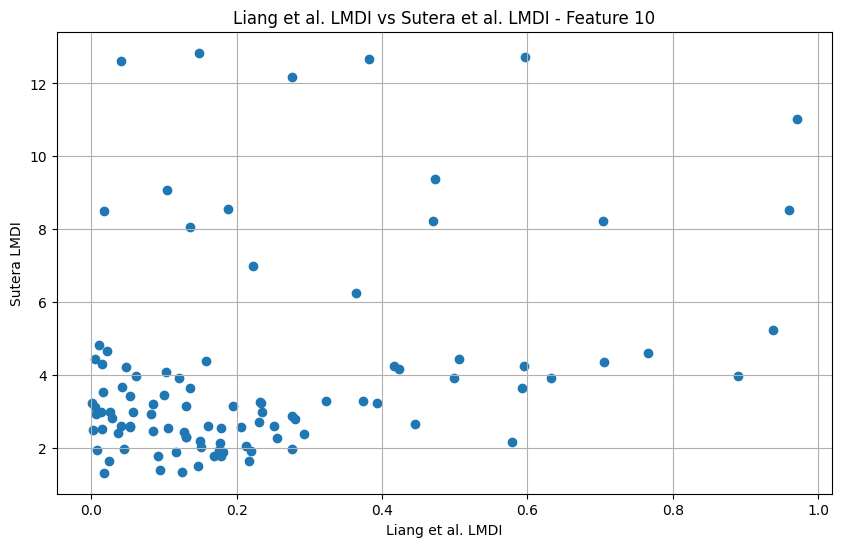

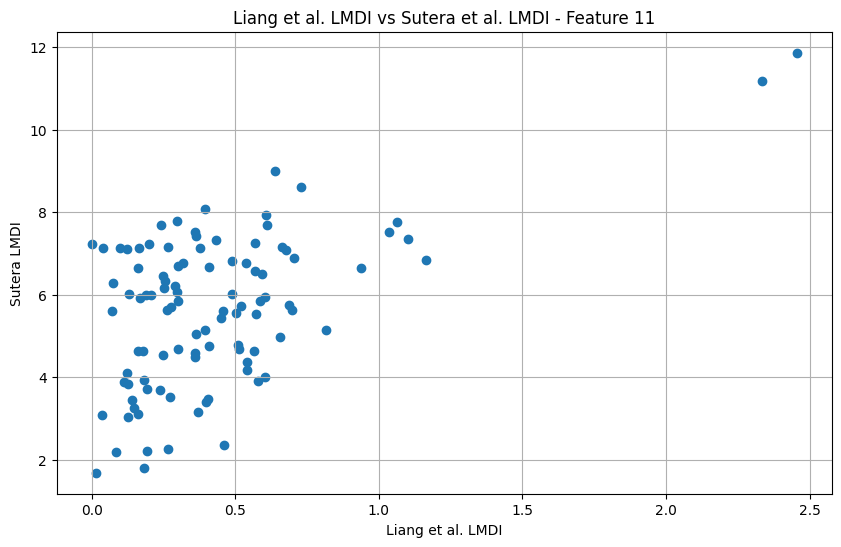

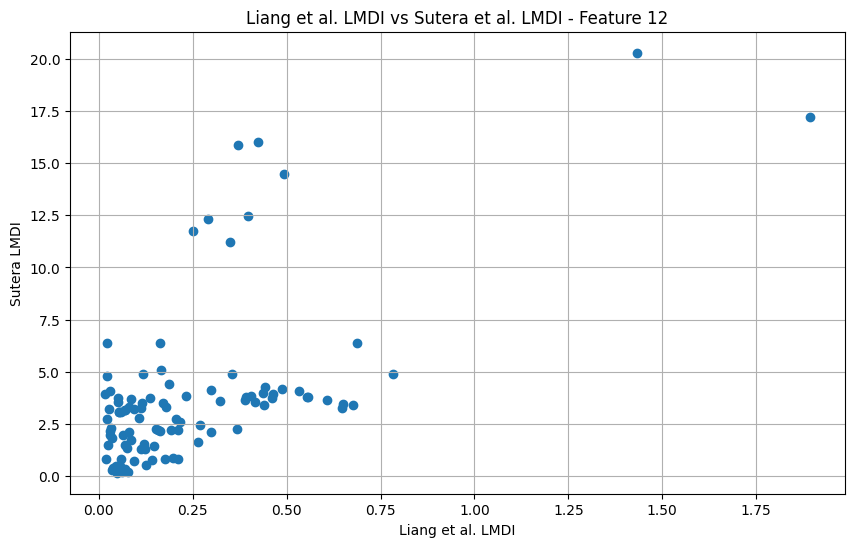

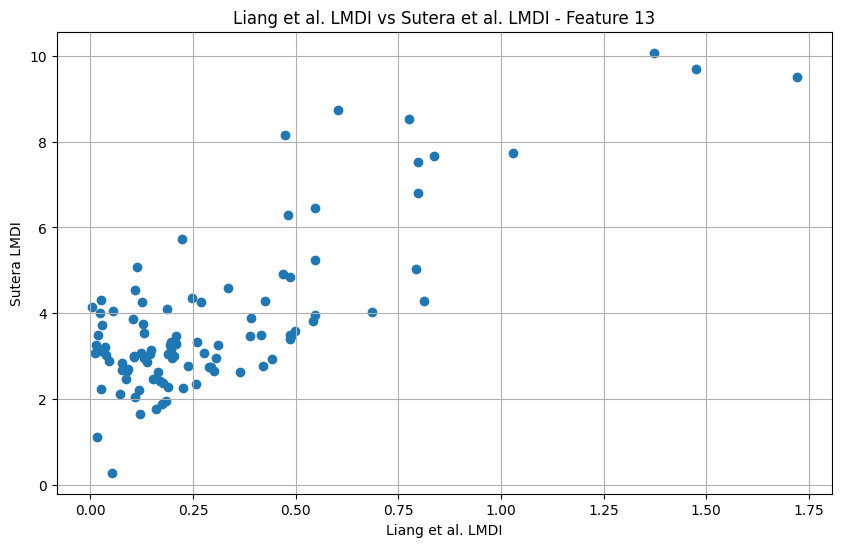

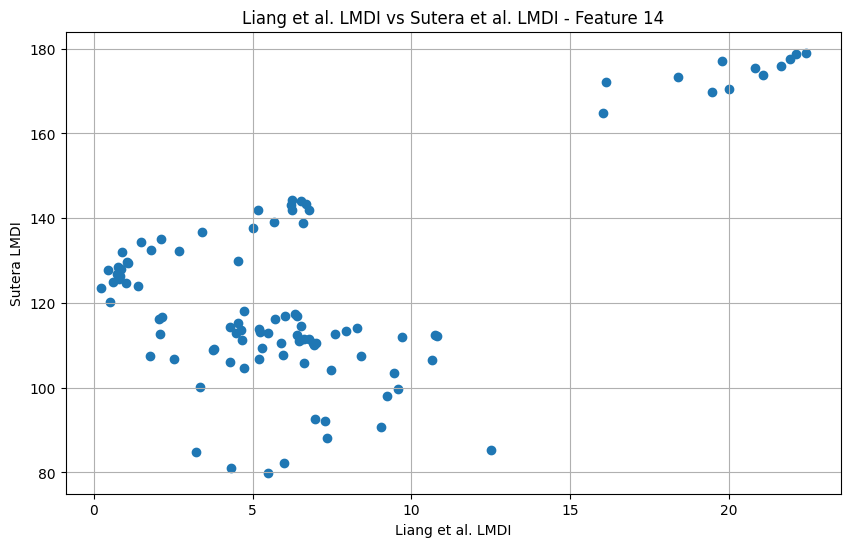

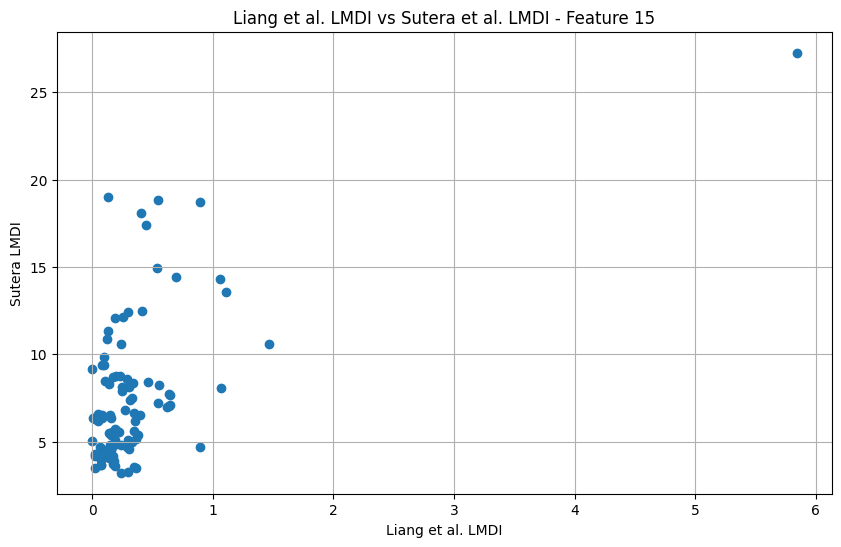

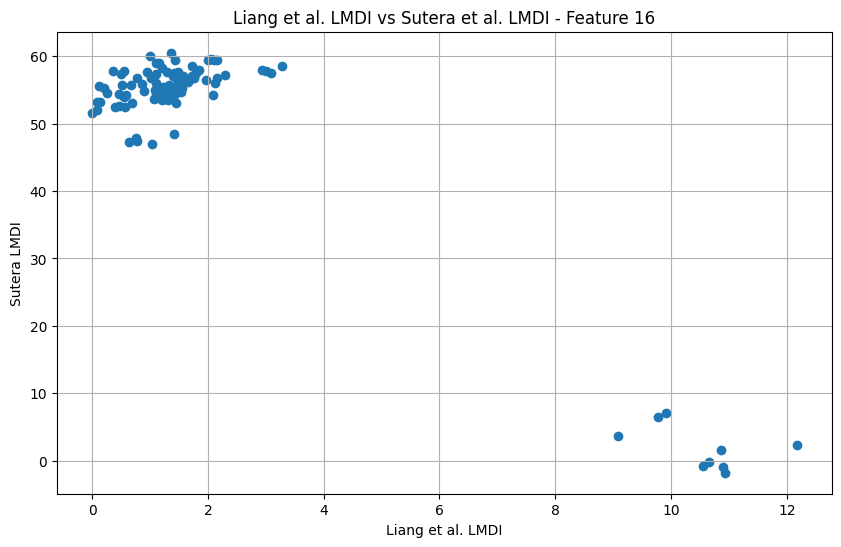

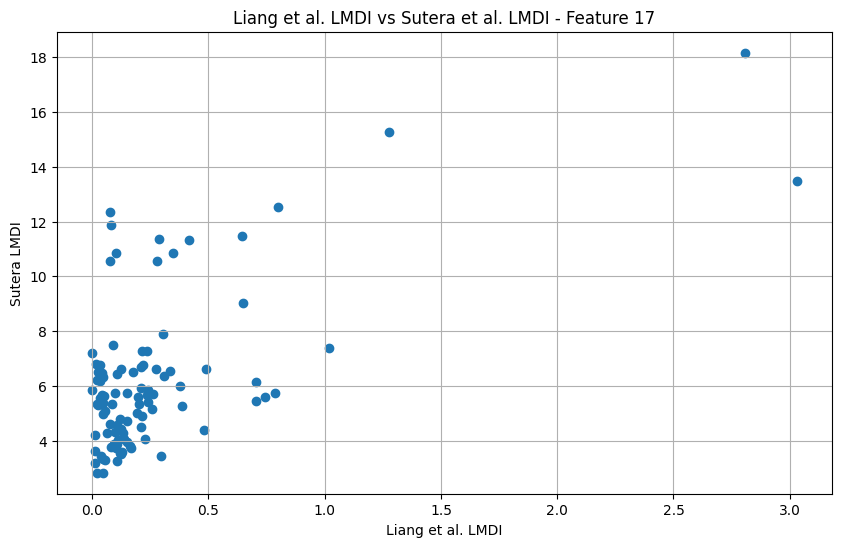

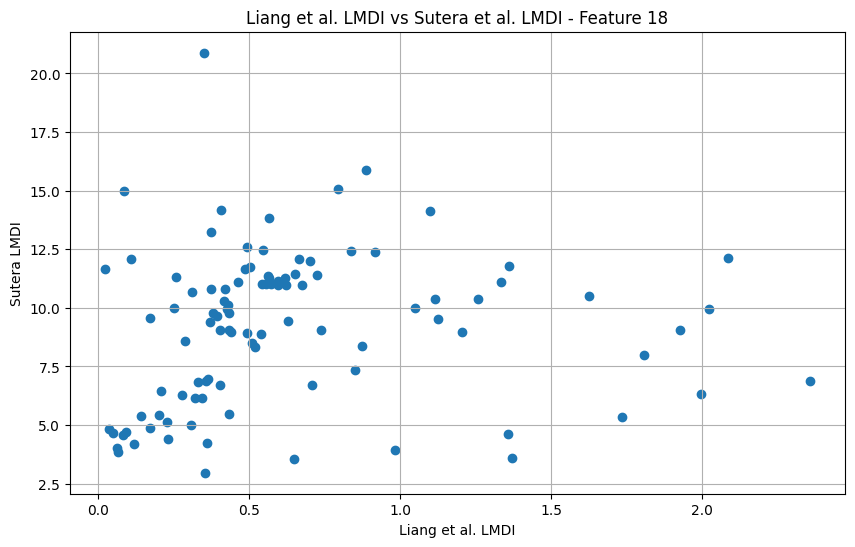

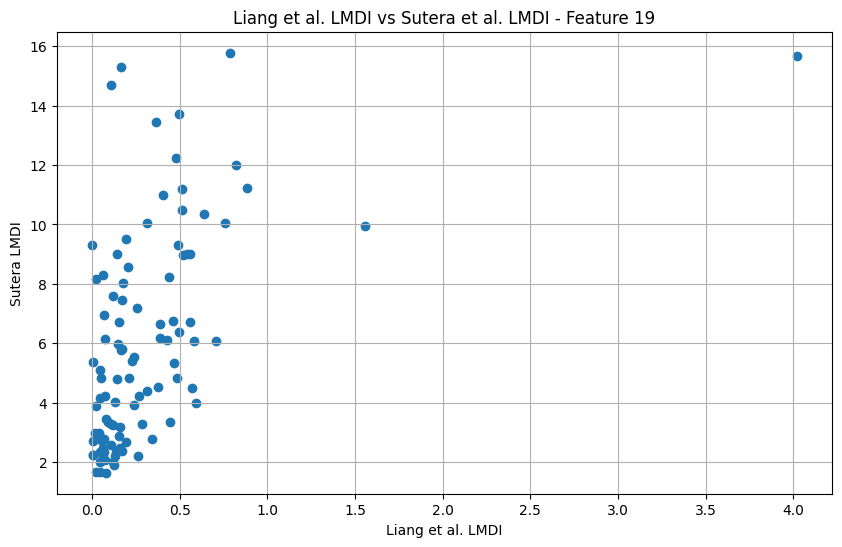

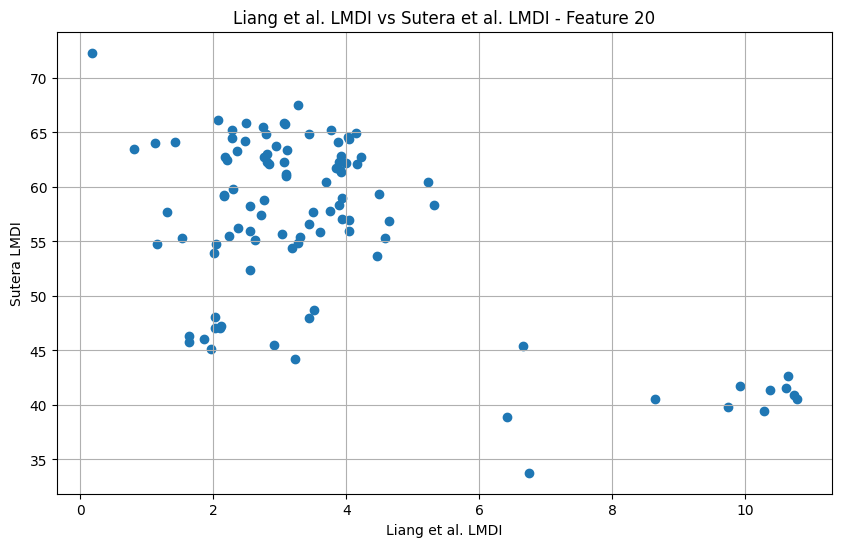

In [32]:
# for each feature/column, plot lmdi vs lmdi baseline in scatterplot
import matplotlib.pyplot as plt
for i in range(lmdi.shape[1]):
    plt.figure(figsize=(10, 6))
    plt.scatter(lmdi[:, i], lmdi_baseline[:, i])
    plt.xlabel("Liang et al. LMDI")
    plt.ylabel("Sutera LMDI")
    plt.title(f"Liang et al. LMDI vs Sutera et al. LMDI - Feature {i}")
    plt.grid()
    plt.show()